In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("../data/raw/Border_Crossing_Entry_Data.csv")

In [4]:
df.head()

,Port Name,State,Port Code,Border,Date,Measure,Value,Latitude,Longitude,Point
0,Jackman,Maine,104,US-Canada Border,Jan 2024,Trucks,6556,45.806,-70.397,POINT (-70.396722 45.805661)
1,Porthill,Idaho,3308,US-Canada Border,Apr 2024,Trucks,98,49.000,-116.499,POINT (-116.49925 48.999861)
2,San Luis,Arizona,2608,US-Mexico Border,Apr 2024,Buses,10,32.485,-114.782,POINT (-114.7822222 32.485)
3,Willow Creek,Montana,3325,US-Canada Border,Jan 2024,Pedestrians,2,49.000,-109.731,POINT (-109.731333 48.999972)
4,Warroad,Minnesota,3423,US-Canada Border,Jan 2024,Personal Vehicle Passengers,9266,48.999,-95.377,POINT (-95.376555 48.999)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 406720 entries, 0 to 406719
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Port Name  406720 non-null  str    
 1   State      406715 non-null  str    
 2   Port Code  406720 non-null  int64  
 3   Border     406720 non-null  str    
 4   Date       406720 non-null  str    
 5   Measure    406720 non-null  str    
 6   Value      406720 non-null  int64  
 7   Latitude   406713 non-null  float64
 8   Longitude  406713 non-null  float64
 9   Point      406713 non-null  str    
dtypes: float64(2), int64(2), str(6)
memory usage: 31.0 MB


In [8]:
df.describe()

,Port Code,Value,Latitude,Longitude
count,406720.000000,4.067200e+05,406713.000000,406713.000000
mean,2444.752872,2.915316e+04,43.955994,-99.698968
std,1204.736291,1.494545e+05,8.155207,18.263069
min,101.000000,0.000000e+00,25.952000,-141.001000
25%,2304.000000,0.000000e+00,42.999000,-114.728000
50%,3012.000000,1.560000e+02,48.122000,-101.628000
75%,3401.000000,3.121000e+03,49.000000,-84.361000
max,3814.000000,4.447374e+06,62.615000,-66.980000


In [10]:
df.describe(include="object")

/tmp/ipykernel_44696/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Port Name,State,Border,Date,Measure,Point
count,406720,406715,406720,406720,406720,406713
unique,120,14,2,360,12,116
top,Eastport,North Dakota,US-Canada Border,Oct 2010,Personal Vehicles,POINT (-115.388018 32.673389)
freq,6896,65349,310603,1356,38870,7573


In [11]:
df.describe(include="all")

,Port Name,State,Port Code,Border,Date,Measure,Value,Latitude,Longitude,Point
count,406720,406715,406720.000000,406720,406720,406720,4.067200e+05,406713.000000,406713.000000,406713
unique,120,14,NaN,2,360,12,NaN,NaN,NaN,116
top,Eastport,North Dakota,NaN,US-Canada Border,Oct 2010,Personal Vehicles,NaN,NaN,NaN,POINT (-115.388018 32.673389)
freq,6896,65349,NaN,310603,1356,38870,NaN,NaN,NaN,7573
mean,NaN,NaN,2444.752872,NaN,NaN,NaN,2.915316e+04,43.955994,-99.698968,NaN
std,NaN,NaN,1204.736291,NaN,NaN,NaN,1.494545e+05,8.155207,18.263069,NaN
min,NaN,NaN,101.000000,NaN,NaN,NaN,0.000000e+00,25.952000,-141.001000,NaN
25%,NaN,NaN,2304.000000,NaN,NaN,NaN,0.000000e+00,42.999000,-114.728000,NaN
50%,NaN,NaN,3012.000000,NaN,NaN,NaN,1.560000e+02,48.122000,-101.628000,NaN
75%,NaN,NaN,3401.000000,NaN,NaN,NaN,3.121000e+03,49.000000,-84.361000,NaN


In [9]:
df.shape

(406720, 10)

In [55]:
df.isnull().sum()

Port Name        0
State            5
Port Code        0
Border           0
Date             0
Measure          0
Value            0
Latitude         7
Longitude        7
Value_log        0
Traffic_Level    0
dtype: int64

In [14]:
df["Date"]=pd.to_datetime(df["Date"])

/tmp/ipykernel_44696/1380596044.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"]=pd.to_datetime(df["Date"])


In [15]:
df["Port Code"]=df["Port Code"].astype("category")

In [16]:
df=df.drop(columns=["Point"])

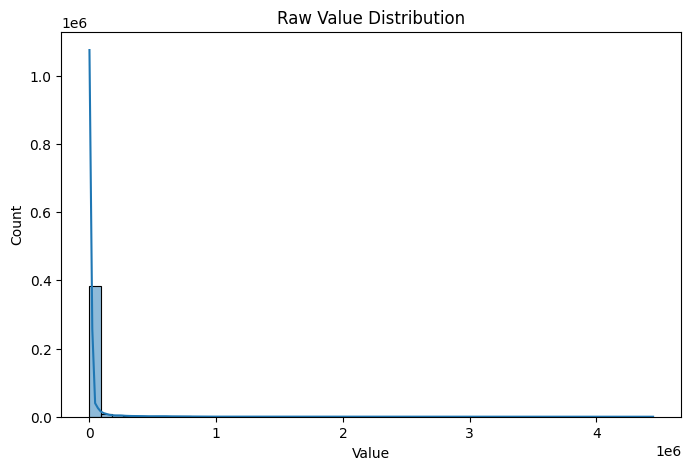

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Value"],bins=50,kde=True)
plt.title("Raw Value Distribution")
plt.show()

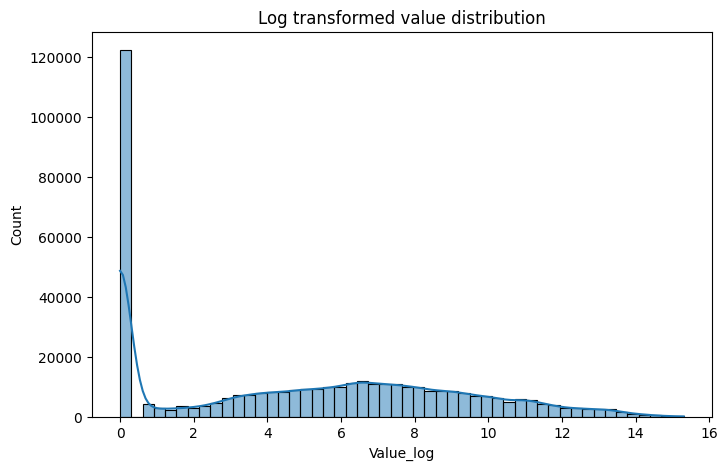

In [19]:
df["Value_log"]=np.log1p(df["Value"])
plt.figure(figsize=(8,5))
sns.histplot(df["Value_log"],bins=50, kde=True)
plt.title("Log transformed value distribution")
plt.show()

In [21]:
print("Raw skew: ", df["Value"].skew())
print("Log skew: ", df["Value_log"].skew())

Raw skew:  10.784413643693581
Log skew:  0.2145907287988456


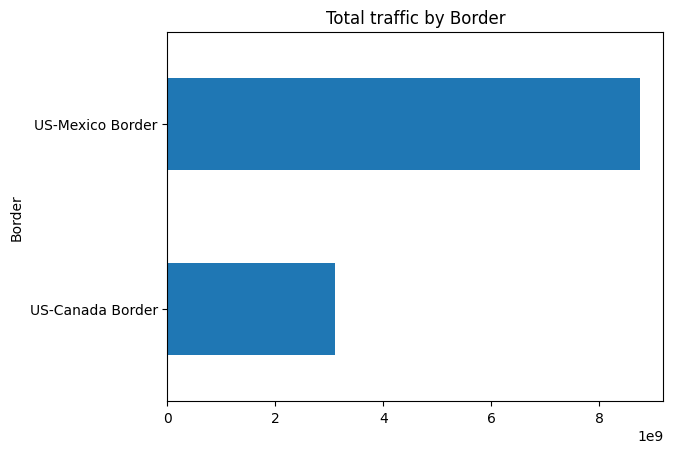

In [26]:
df.groupby("Border")["Value"].sum().plot(kind="barh")
plt.title("Total traffic by Border")
plt.show()

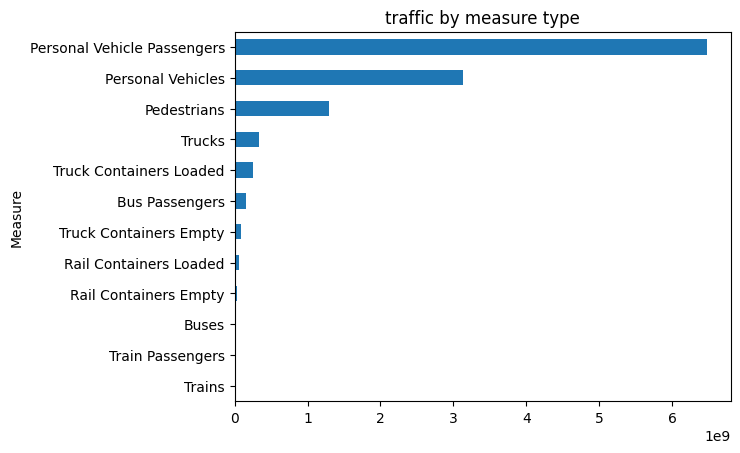

In [29]:
df.groupby("Measure")["Value"].sum().sort_values().plot(kind="barh")
plt.title("traffic by measure type")
plt.show()

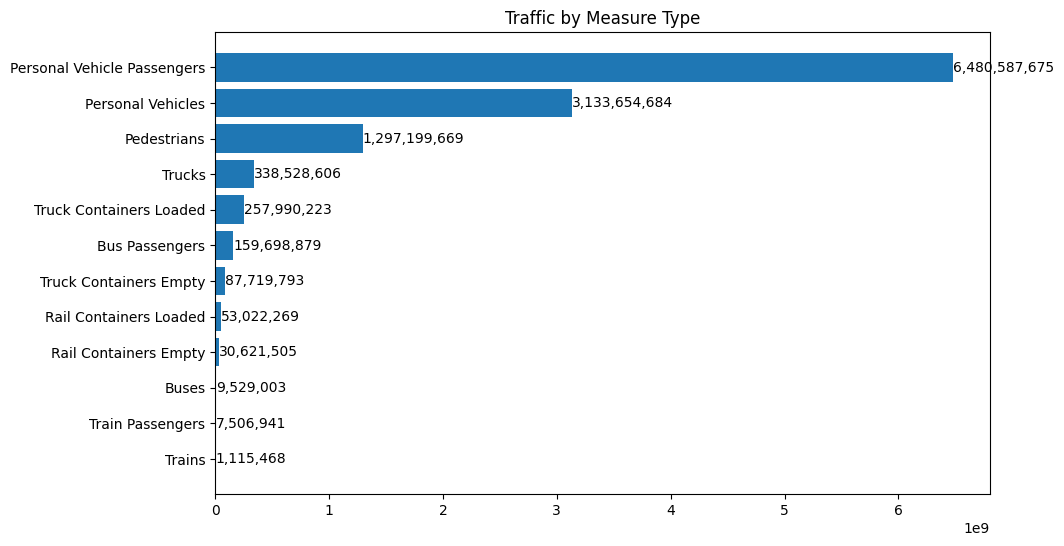

In [32]:

measure_traffic = df.groupby("Measure")["Value"].sum().sort_values()

plt.figure(figsize=(10,6))
bars = plt.barh(measure_traffic.index, measure_traffic.values)

plt.title("Traffic by Measure Type")

for i, v in enumerate(measure_traffic.values):
    plt.text(v, i, f"{int(v):,}", va='center')

plt.show()



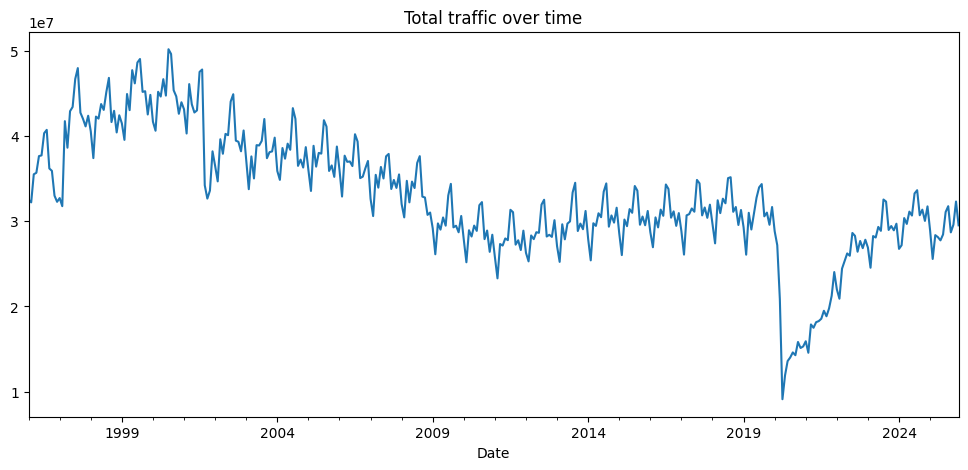

In [34]:
monthly= df.groupby("Date")["Value"].sum()
plt.figure(figsize=(12,5))
monthly.plot()
plt.title("Total traffic over time")
plt.show()

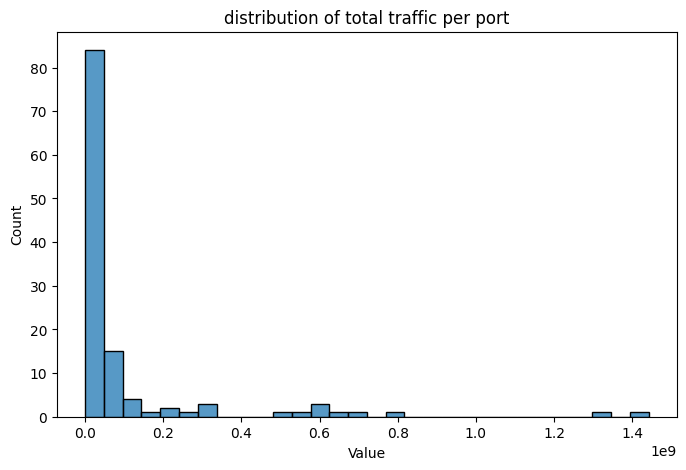

In [35]:
port_traffic=df.groupby("Port Name")["Value"].sum()
plt.figure(figsize=(8,5))
sns.histplot(port_traffic,bins=30)
plt.title("distribution of total traffic per port")
plt.show()

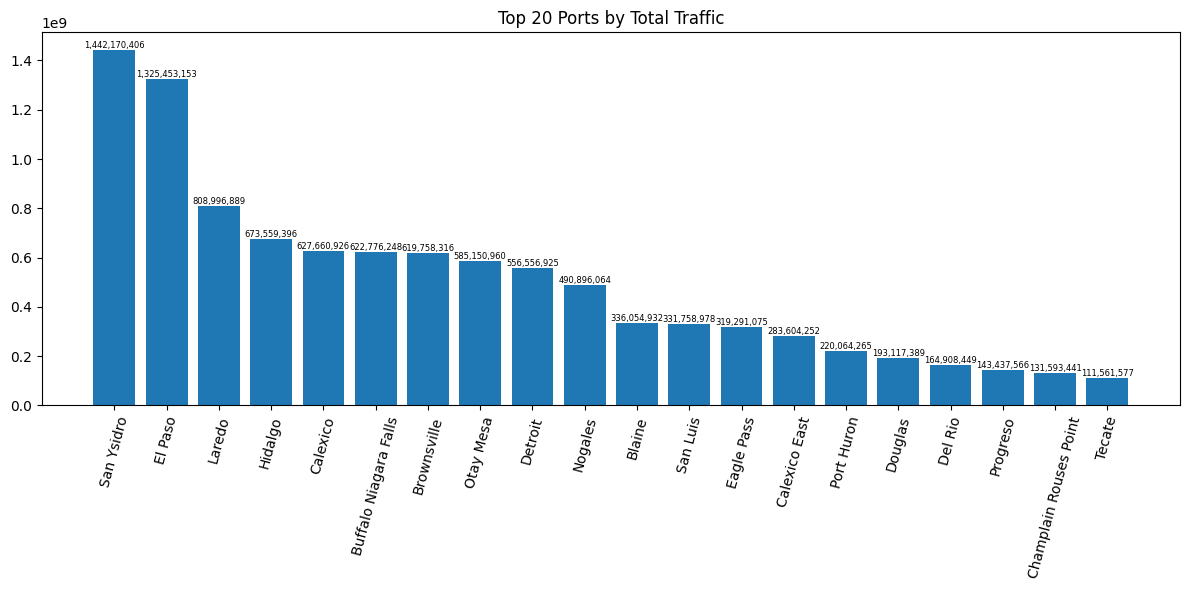

In [46]:
import matplotlib.pyplot as plt

port_traffic = (
    df.groupby("Port Name")["Value"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))
bars = plt.bar(port_traffic.index, port_traffic.values)

plt.xticks(rotation=75)
plt.title("Top 20 Ports by Total Traffic")

# Add value labels
for i, v in enumerate(port_traffic.values):
    plt.text(i, v, f"{int(v):,}", ha='center', va='bottom', fontsize=6)

plt.tight_layout()
plt.show()


In [47]:
df["Traffic_Level"] = pd.qcut(
    df["Value"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)


ValueError: Bin edges must be unique: Index([0.0, 0.0, 156.0, 3121.0, 4447374.0], dtype='float64', name='Value').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [49]:
(df["Value"] == 0).mean() * 100


np.float64(30.095151455546816)

In [50]:
non_zero = df[df["Value"] > 0]["Value"]


In [51]:
non_zero.quantile([0.33, 0.66])


0.33     241.0
0.66    3630.0
Name: Value, dtype: float64

In [52]:
bins = [-1, 0, 240, 3630, df["Value"].max()]
labels = ["Zero", "Low", "Medium", "High"]

df["Traffic_Level"] = pd.cut(
    df["Value"],
    bins=bins,
    labels=labels
)


In [53]:
df["Traffic_Level"].value_counts(normalize=True) * 100


Traffic_Level
Zero      30.095151
High      23.766965
Medium    23.071400
Low       23.066483
Name: proportion, dtype: float64

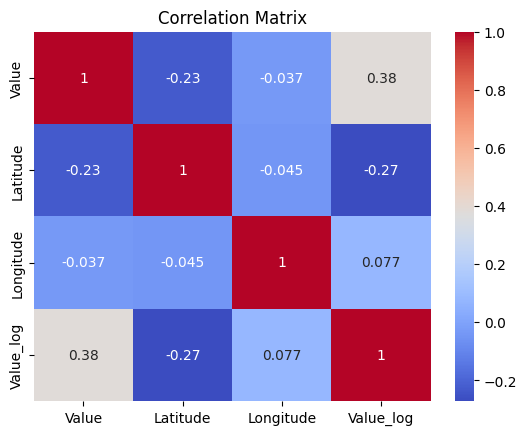

In [54]:
numeric_cols = df.select_dtypes(include=["float64","int64"]).columns

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
